# Code to fix your flat

This code is basically set up as a notebook style of the flat making process, and goes through each step, ending at the traces for the order. 

In [52]:
# import 
import sys
import os
import argparse
import configparser
from pathlib import Path
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import scipy.linalg
import scipy.ndimage
import astropy.io.fits as fits

sys.path.append(str(Path.cwd().parents[1]))
from kahe.calibration.make_flat import combine_flats, trace_edges, fit_and_divide
from kahe.instruments import nirspec

In [53]:
# Set the datta directory
flats_dir = "../../../KOI7368_260704/raw/flats"
flats = [fits.getdata(f) for f in Path(flats_dir).glob("*.fits")]
print(f"Loaded {len(flats)} flat frames from {flats_dir}")

Loaded 20 flat frames from ../../../KOI7368_260704/raw/flats


In [54]:
# Set the dark directory 
master_dark =  "../../../KOI7368_260704/cals/KOI7368_260704_masterdark.fits"
with fits.open(Path(master_dark)) as hdul:
    dark_data = hdul[0].data
    dark_header = hdul[0].header

In [55]:
# Combine the flats to visualize the traces 

flat, _ = combine_flats(flats_dir, 
                        masterdark = dark_data)

Processing 20 flat frames...
   [1/20] nspec260724_0013.fits
   [2/20] nspec260724_0020.fits
   [3/20] nspec260724_0023.fits
   [4/20] nspec260724_0012.fits
   [5/20] nspec260724_0025.fits
   [6/20] nspec260724_0016.fits
   [7/20] nspec260724_0015.fits
   [8/20] nspec260724_0017.fits
   [9/20] nspec260724_0026.fits
   [10/20] nspec260724_0021.fits
   [11/20] nspec260724_0022.fits
   [12/20] nspec260724_0014.fits
   [13/20] nspec260724_0008.fits
   [14/20] nspec260724_0024.fits
   [15/20] nspec260724_0018.fits
   [16/20] nspec260724_0019.fits
   [17/20] nspec260724_0010.fits
   [18/20] nspec260724_0011.fits
   [19/20] nspec260724_0007.fits
   [20/20] nspec260724_0009.fits
Combined 20 flat frames


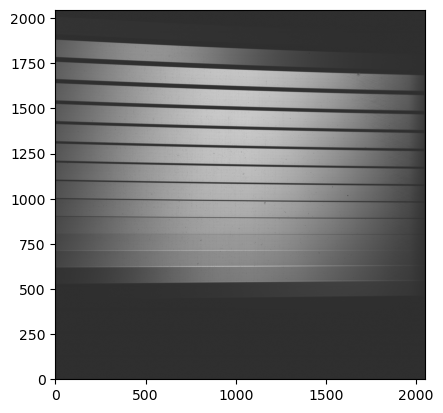

In [56]:
# Imshow the flat
plt.imshow(flat, cmap='gray', origin='lower')

# Great now trace the edges

Tracing edges...
  Found 13 upper positions: [ 535  622  710  802  894  989 1087 1188 1291 1398 1508 1621 1738]
  Found 13 lower positions: [ 625  712  800  891  984 1079 1177 1278 1381 1488 1598 1712 1829]


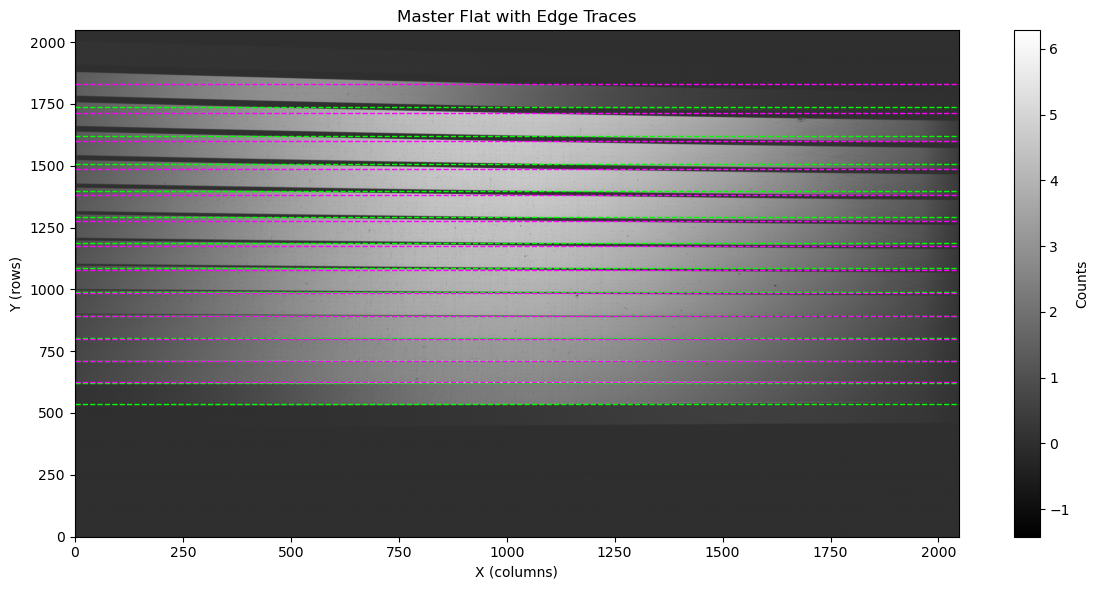

  Tracing 1 order(s): [10]
    Tracing order 10...


/home/chase/anaconda3/envs/pwinds/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


In [62]:
top_edges, bottom_edges = trace_edges(flat,
                                      FILTER=None, 
                                      show_plots=True, orders=-3)

As a reference, here is the order numbers in Y band from the line list: 
![here](../calibration/yband_arcs.png)

In [63]:
top_edges, bottom_edges

(array([[1543.53109918, 1543.48233783, 1543.43361026, ..., 1514.43764039,
         1514.45798228, 1514.47835796]]),
 array([[1637.40635425, 1637.3624249 , 1637.31850658, ..., 1570.60690512,
         1570.58551595, 1570.5641378 ]]))

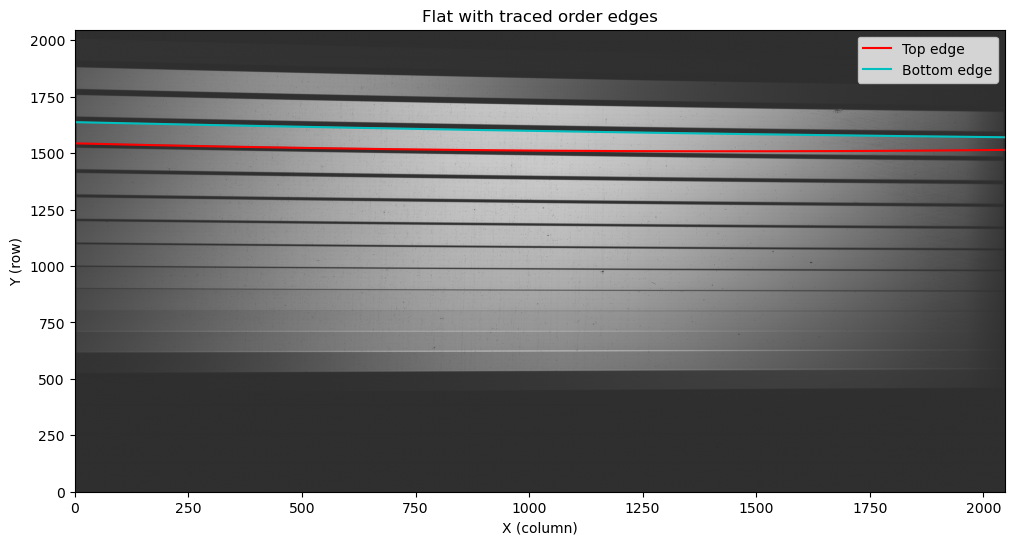

In [66]:
# Overlay traced edges on the flat
x = np.arange(flat.shape[1])  # columns

plt.figure(figsize=(12, 6))
plt.imshow(flat, cmap="gray", origin="lower", aspect="auto")

top = np.atleast_2d(top_edges)
bot = np.atleast_2d(bottom_edges)

for i in range(top.shape[0]):
    plt.plot(x, top[i], "r-", lw=1.5, label="Top edge" if i == 0 else None)
    plt.plot(x, bot[i], "c-", lw=1.5, label="Bottom edge" if i == 0 else None)

plt.xlim(0, flat.shape[1] - 1)
plt.ylim(0, flat.shape[0] - 1)
plt.legend()
plt.title("Flat with traced order edges")
plt.xlabel("X (column)")
plt.ylabel("Y (row)")
plt.show()